PASSO 1: Configuração e definição da função geradora

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns


# Configuração visual para gráficos padronizados.
sns.set_theme(style="whitegrid", palette="muted")


def analisar_variavel(df, coluna, titulo, xlabel, percentis=[0.25, 0.50, 0.75, 0.90, 0.95], limite_x=None):
    """
        Função modular que, para qualquer variável numérica passada, gera:
        - Histograma;
        - Boxplot;
        - Tabela de Quartis.
    """

    # Aplica o limite no eixo X apenas para melhoria de plotagem visual, se fornecido
    if limite_x is not None:
        df_plot = df[df[coluna] <= limite_x]
        aviso = f" - ZOOM APLICADO"
    else:
        df_plot = df
        aviso = ""

    # Cria uma figura com dois gráficos lado a lado.
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # GRÁFICO 1: Histograma.
    sns.histplot(df_plot[coluna], bins=30, kde=True, ax=ax[0])
    ax[0].set_title(f"Histograma: {titulo}{aviso}")
    ax[0].set_xlabel(xlabel)
    ax[0].set_ylabel("Frequência (Qtd. de Licitações)")

    # GRÁFICO 2: Boxplot.
    sns.boxplot(x=df_plot[coluna], ax=ax[1])
    ax[1].set_title(f"Boxplot: {titulo}{aviso}")
    ax[1].set_xlabel(xlabel)

    plt.tight_layout()
    plt.show()

    # Exibe Quartis e Percentis.
    print(f"== ESTATÍSTICA DESCRITIVA: {titulo.upper()} ==")
    display(df[coluna].describe(percentiles=percentis).to_frame().T.round(2))

PASSO 2: Carga dos dados

In [19]:
BASE_DIR = Path.cwd().parent
ARQUIVO_BASE = BASE_DIR / "data" / "processed" / "base_tratada.xlsx"

df_master = pd.read_excel(ARQUIVO_BASE)
print(f"Base carregada com sucesso! Total de registros: {df_master.shape[0]}")

Base carregada com sucesso! Total de registros: 49078


PASSO 3: Análise da competitividade

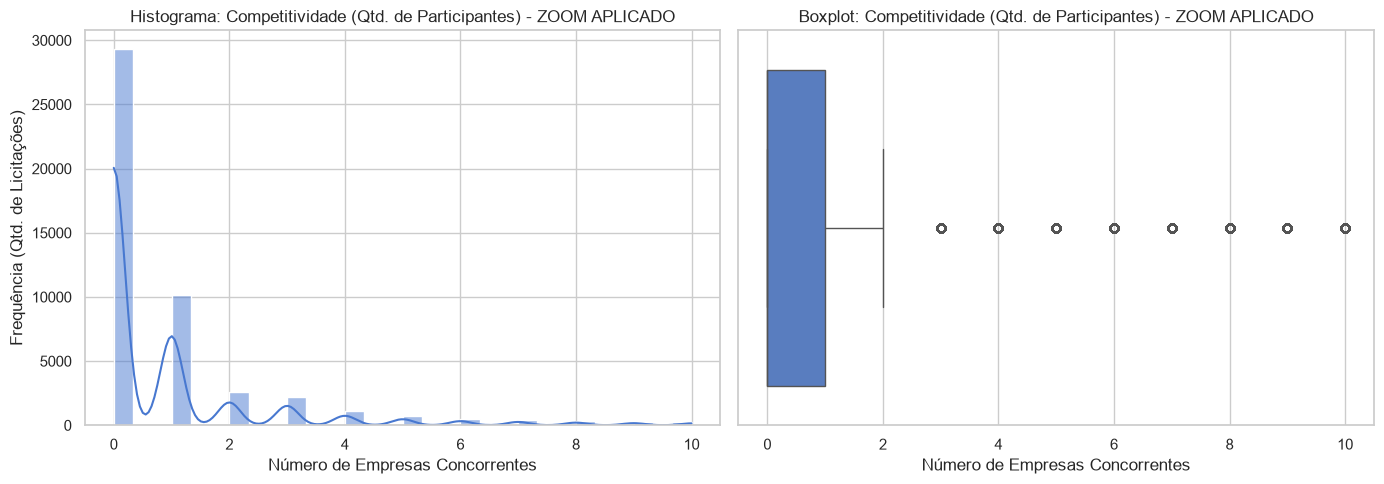

== ESTATÍSTICA DESCRITIVA: COMPETITIVIDADE (QTD. DE PARTICIPANTES) ==


,count,mean,std,min,25%,50%,75%,90%,95%,max
qtd_participantes,49078.0,1.48,4.32,0.0,0.0,0.0,1.0,3.0,7.0,124.0


In [33]:
analisar_variavel(
    df=df_master,
    coluna='qtd_participantes',
    titulo='Competitividade (Qtd. de Participantes)',
    xlabel='Número de Empresas Concorrentes',
    limite_x=10
)

PASSO 4: Análise do desconto obtido

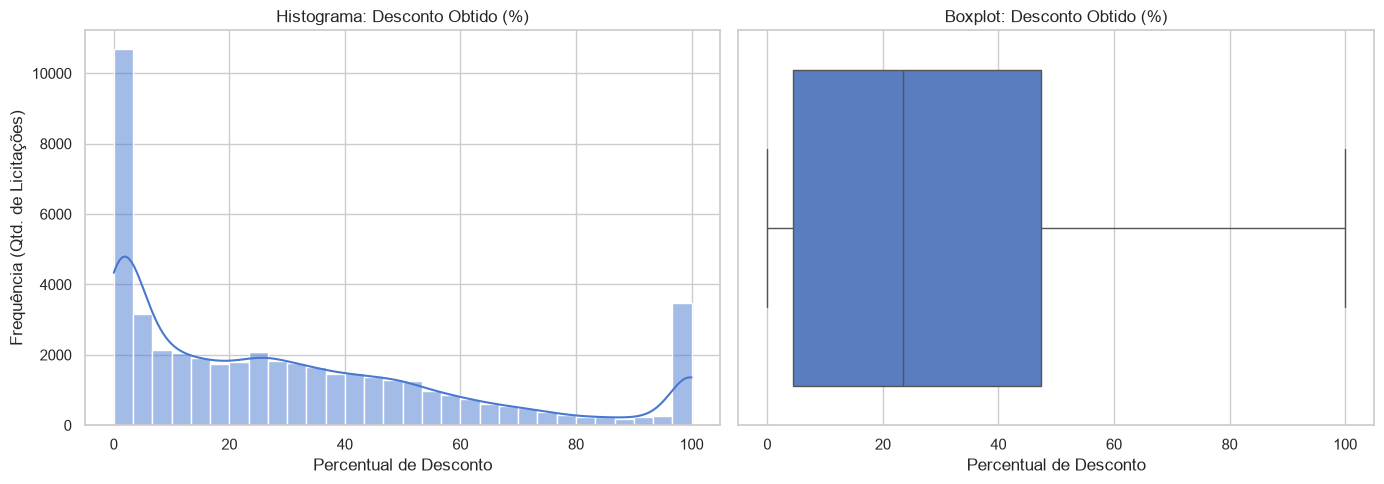

== ESTATÍSTICA DESCRITIVA: DESCONTO OBTIDO (%) ==


,count,mean,std,min,25%,50%,75%,90%,95%,max
percentual_desconto,47221.0,30.77,29.85,0.0,4.42,23.56,47.34,78.86,100.0,100.0


In [6]:
# Filtra descontos válidos (entre 0% e 100%).
df_desconto = df_master[(df_master['percentual_desconto'] >= 0) & (df_master['percentual_desconto'] <= 100)]

analisar_variavel(
    df=df_desconto,
    coluna='percentual_desconto',
    titulo='Desconto Obtido (%)',
    xlabel='Percentual de Desconto'
)

PASSO 5: Análise da concentração de vitórias

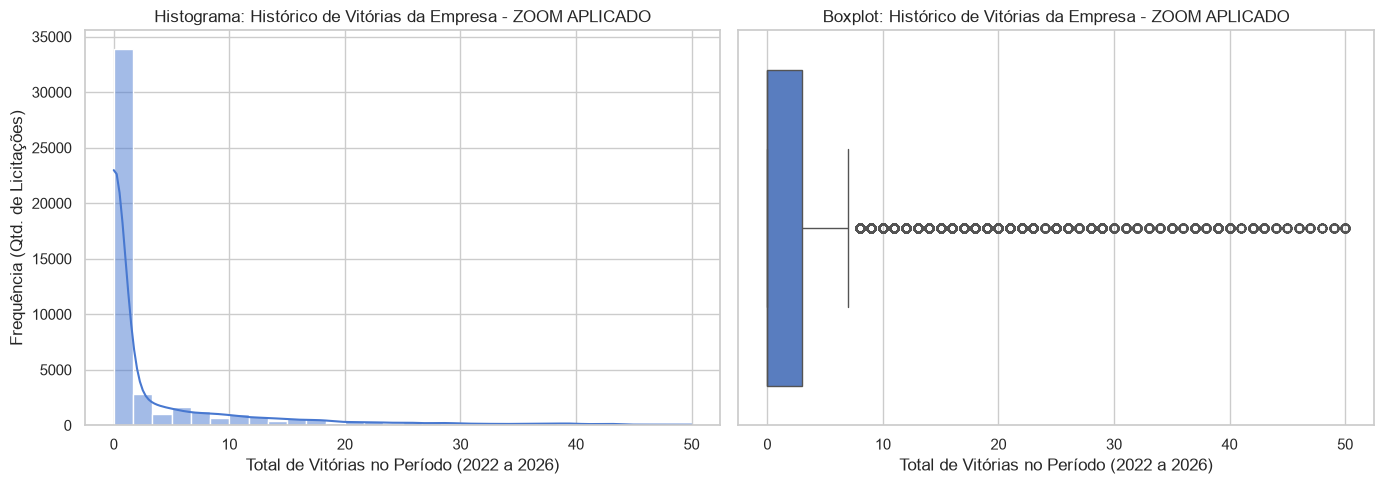

== ESTATÍSTICA DESCRITIVA: HISTÓRICO DE VITÓRIAS DA EMPRESA ==


,count,mean,std,min,25%,50%,75%,90%,95%,max
historico_vitorias_empresa_vencedora,49078.0,6.51,23.74,0.0,0.0,0.0,4.0,17.0,33.0,795.0


In [34]:
analisar_variavel(
    df=df_master,
    coluna='historico_vitorias_empresa_vencedora',
    titulo='Histórico de Vitórias da Empresa',
    xlabel='Total de Vitórias no Período (2022 a 2026)',
    limite_x=50
)

PASSO 6: Análise do desbalanceamento da base

== DISTRIBUIÇÃO DA VARIÁVEL ALVO (GABARITO) ==


,Quantidade (Absoluta),Percentual (%)
risco,,
Baixo Risco,35572,72.48
Médio Risco,11455,23.34
Alto Risco,2051,4.18


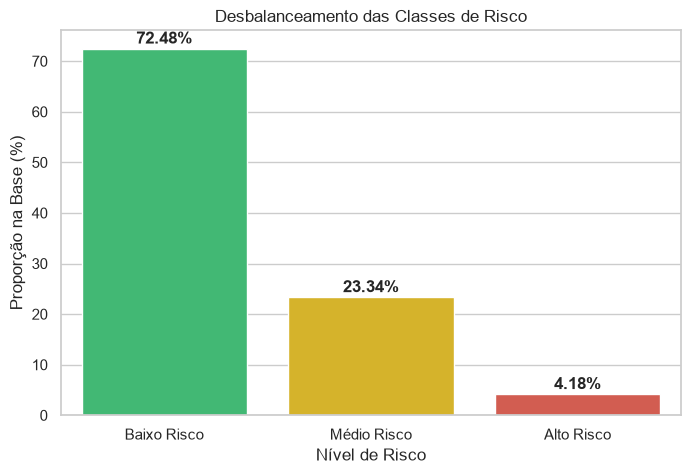

In [17]:
# Calcula proporções.
dist_percentual = df_master['risco'].value_counts(normalize=True) * 100
dist_absoluta = df_master['risco'].value_counts()

df_distribuicao = pd.DataFrame({
    'Quantidade (Absoluta)': dist_absoluta,
    'Percentual (%)': dist_percentual.round(2)
})

print("== DISTRIBUIÇÃO DA VARIÁVEL ALVO (GABARITO) ==")
display(df_distribuicao)

# Gráfico de Barras para evidenciar o desbalanceamento.
plt.figure(figsize=(8, 5))
cores = ['#2ecc71', '#f1c40f', '#e74c3c']
ax = sns.barplot(x=df_distribuicao.index, y=df_distribuicao['Percentual (%)'], palette=cores, hue=df_distribuicao.index, legend=False)

plt.title("Desbalanceamento das Classes de Risco")
plt.ylabel("Proporção na Base (%)")
plt.xlabel("Nível de Risco")

# Adiciona o número em % em cima de cada barra.
for index, value in enumerate(df_distribuicao['Percentual (%)']):
    plt.text(index, value + 1, f"{value}%", ha='center', fontweight='bold')

plt.show()